<a href="https://colab.research.google.com/github/olblinova/python_for_ds_tasks-is-available/blob/main/%22HW_11_1_%D0%92%D1%96%D0%B7%D1%83%D0%B0%D0%BB%D1%96%D0%B7%D0%B0%D1%86%D1%96%D1%8F_%D0%B4%D0%B0%D0%BD%D0%B8%D1%85_%D0%B7_Pandas_ipynb%22.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Домашнє завдання: Візуалізація даних з Pandas

## Опис завдання
У цьому домашньому завданні ви працюватимете з датасетом про оренду велосипедів `yulu_rental.csv`. Датасет містить інформацію про кількість орендованих велосипедів залежно від погодних умов, сезону та інших факторів.
Набір даних взяти з Kaggle. Посилання на оригінальний [опис](https://www.kaggle.com/datasets/ranitsarkar01/yulu-bike-sharing-data?select=yulu_bike_sharing_dataset.csv).

**Опис колонок:**
- `datetime` - дата та час
- `season` - квартал (1-Q1, 2-Q2, 3-Q3, 4-Q4)
- `holiday` - чи є день святковим (0=ні, 1=так)
- `workingday` - чи є день робочим (0=ні, 1=так)
- `weather` - погодні умови (1=ясно, 2=туман, 3=легкий дощ, 4=сильний дощ)
- `temp` - температура в градусах Цельсія
- `atemp` - відчувається як температура
- `humidity` - вологість (%)
- `windspeed` - швидкість вітру
- `casual` - кількість випадкових користувачів
- `registered` - кількість зареєстрованих користувачів
- `count` - загальна кількість орендованих велосипедів



---
🌱 Коментар щодо сезонності

Колонка season у датасеті представляє саме квартали року, а не метеорологічні сезони. Тому всі аналізи сезонності ви можете будувати на основі кварталів.

Водночас дані були зібрані в Індії, де поділ на сезони інший, ніж у Європі чи США. Якщо ви хочете дослідити сезонність відповідно до індійської системи сезонів, можна створити окрему колонку.


Справжні сезони в Індії:

| Сезон        | Місяці                     |
| ------------ | -------------------------- |
| Winter       | December–February (12,1,2) |
| Summer       | March–May (3,4,5)          |
| Monsoon      | June–September (6,7,8,9)   |
| Post-monsoon | October–November (10,11)   |


Тоді потрібно зробити нову колонку weather_season_india, мапнувши місяці так:

12, 1, 2 → 1 (Winter)

3, 4, 5 → 2 (Summer)

6–9 → 3 (Monsoon)

10–11 → 4 (Post-Monsoon)

## Підготовка даних


In [4]:
import pandas as pd
import matplotlib.pyplot as plt

# Завантаження даних
df = pd.read_csv('/content/drive/MyDrive/data/yulu_rental.csv')

In [5]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [7]:
# Перетворення datetime у правильний формат
df['datetime'] = pd.to_datetime(df['datetime'])
df.set_index('datetime', inplace=True)

# Додаємо додаткові колонки для аналізу
df['date'] = df.index.date
df['day'] = df.index.day
df['week'] = df.index.isocalendar().week
df['weekday_num'] = df.index.weekday
df['weekday'] = df.index.day_name()
df['year'] = df.index.year
df['month'] = df.index.month
df['hour'] = df.index.hour

## Завдання 0: Перегляд даних
**Завдання:**
Перегляньте дані, їх розмір, та напишіть висновок:
- скільки даних в наборі
- який рівень деталізації мають ці дані, тобто за який період міститься дані в одному рядку даних ?

In [8]:
print("Кількість рядків:", df.shape[0])
print("Кількість колонок:", df.shape[1])

Кількість рядків: 10886
Кількість колонок: 19


In [9]:
df.index.to_series().diff().value_counts().head()

,count
datetime,
0 days 01:00:00,10820
0 days 02:00:00,36
12 days 01:00:00,13
11 days 01:00:00,8
0 days 03:00:00,5


В одному рядку містяться дані за одну годину. Рівень деталізації - погодинний

## Завдання 1: Базовий лінійний графік

**Завдання:**
1. Згрупуйте дані про кількість орендованих велосипедів (`count`) поденно.
2. Побудуйте з методом `DataFrame.plot()` лінійний графік поденної кількості орендованих велосипедів (`count`) за весь період в даних.
3. Налаштуйте розмір графіка (12x6), додайте заголовок "Динаміка оренди велосипедів" та сітку.
4. Дайте відповіді на питання по цьому графіку. Якщо треба - проведіть додаткові програмні операції для відповідей.

**Питання для інтерпретації:**
1. Як гадаєте, чому графік має "заломи", чим це спричинено і як ви б могли прибрати заломи?
2. Які загальні тенденції ви бачите на графіку?
3. Чи помітні якісь сезонні коливання?
4. Чи є періоди з аномально високими або низькими значеннями і чому на ваш погляд можуть бути ці аномалії?


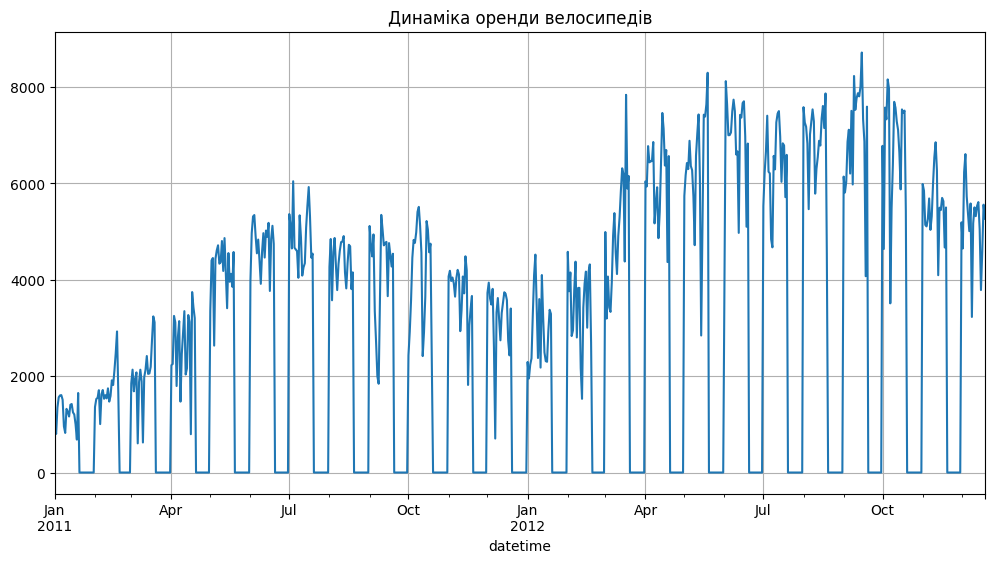

In [10]:
daily_count = df['count'].resample('D').sum()
daily_count.plot(
  figsize=(12, 6),
  title="Динаміка оренди велосипедів",
  grid=True
  )
plt.show()

In [11]:
df.index.day.value_counts().sort_index()

,count
datetime,
1,575
2,573
3,573
4,574
5,575
6,572
7,574
8,574
9,575


1. Заломи на графіку спричинені не реальними коливаннями попиту, а структурною особливістю датасету: дані містять записи тільки за перші 19 днів кожного місяця (дні 20-31 відсутні). Метод resample('D') створює рядки для всіх календарних дат, і для відсутніх днів .sum() повертає 0 замість NaN, що на графіку виглядає як різкі прямокутні провали до нуля. Вирішується заміною нулів на NaN або видаленням цих штучних записів.

<Axes: title={'center': 'Динаміка оренди велосипедів'}, xlabel='datetime'>

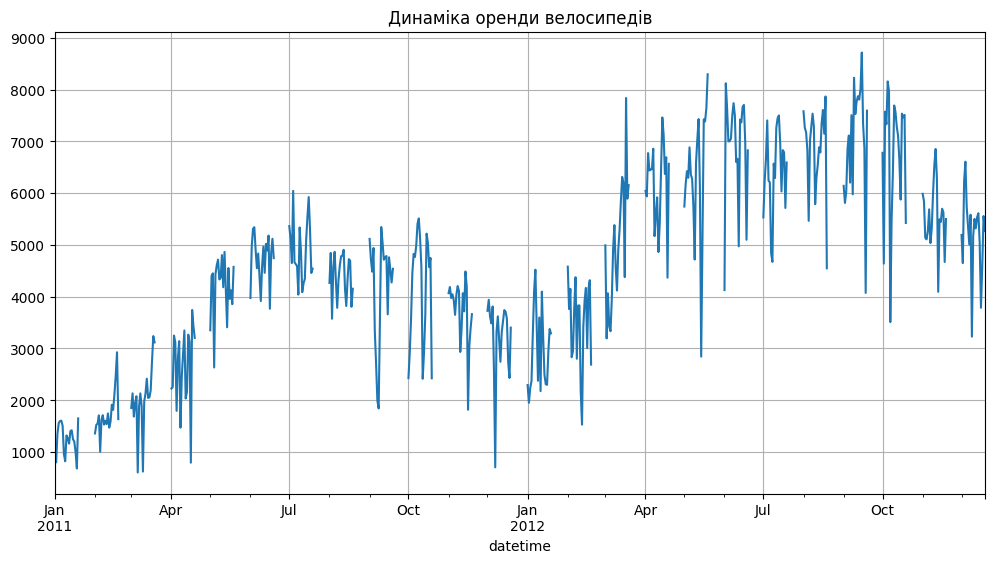

In [12]:
import numpy as np

daily_count = df['count'].resample('D').sum()
daily_count = daily_count.replace(0, np.nan)  # прибираємо штучні нулі

daily_count.plot(figsize=(12, 6), title='Динаміка оренди велосипедів', grid=True)

2. Найпомітніша тенденція — стабільне зростання попиту протягом усього періоду. На початку 2011 року щоденна кількість оренд коливалась в діапазоні приблизно 600-2000, тоді як до кінця 2012 базовий рівень піднявся до 5000-8000

3. Сезонні коливання:
Спад узимку - на початку 2011 (січень-лютий) та знову приблизно листопад 2011 - лютий 2012 значення падають до найнижчих рівнів у своєму періоді.
Зростання навесні — березень-квітень демонструють стійке підвищення.
Пік влітку-восени — найвищі стабільні значення припадають на літні та осінні місяці (липень-жовтень), коли погода найкомфортніша для велопоїздок.
Це логічно узгоджується з кліматом Індії: холодніша зима зменшує бажання їздити на велосипеді, а тепліші сезони стимулюють попит.

4. Є кілька помітних одноденних провалів, які виділяються на фоні сусідніх значень: лютий 2011 — різке падіння приблизно до 600-700, тоді як сусідні дні тримались в районі 1500-2000.
Вересень 2012 — провал до 2800 серед значень 6000-7000 навколо. Ймовірна причина цих аномалій — погодні умови або свята.


## Завдання 2: Аналіз сезонності (Bar Plot)

**Завдання:**
Побудуйте вертикальну стовпчасту діаграму середньої кількості орендованих велосипедів за сезонами(кварталами). Додайте підписи осей і заголовок.

Просунуте доповнення:
1. Позначте квартали не числом, а назвою на візуалізації.
2. Додайте підписи над стовпцями зі значеннями в кожному стовпці.

Дайте відповіді на питання нижче.

**Питання для інтерпретації:**
1. В який квартал найбільша середня кількість оренди велосипедів?
2. Як ви можете пояснити таку сезонну закономірність?
3. У скільки разів відрізняється оренда між найпопулярнішим та найменш популярним кварталми?

In [13]:
# Середня кількість оренд за кварталами
season_avg = df.groupby('season')['count'].mean()

# Назви кварталів
season_names = {
    1: 'Q1',
    2: 'Q2',
    3: 'Q3',
    4: 'Q4'
}

season_avg.index = season_avg.index.map(season_names)

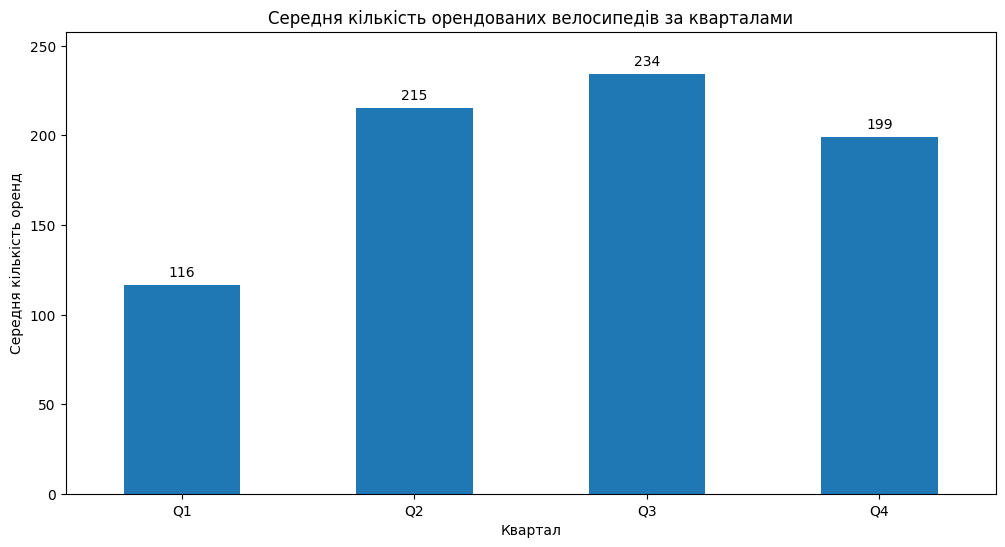

In [14]:
ax = season_avg.plot(
    kind='bar',
    figsize=(12, 6),
    title='Середня кількість орендованих велосипедів за кварталами'
)

plt.xlabel('Квартал')
plt.ylabel('Середня кількість оренд')
plt.xticks(rotation=0)
for i, value in enumerate(season_avg):
    ax.text(i, value + season_avg.max() * 0.02, f'{value:.0f}', ha='center')

plt.ylim(0, season_avg.max() * 1.1)
plt.show()

Найбільша середня еількість арендованих авто у другому і третьому кварталі, бо у тепліші місяці люди частіше користуються велосипедами через комфортнішу температуру та сприятливішу погоду. У холодніші періоди попит нижчий.

In [15]:
season_avg.max() / season_avg.min()

2.0148749597441986

У 2 рази відрізняється оренда між найпопулярнішим та найменш популярним кварталми

## Завдання 3: Динаміка за місяцями (Line Plot)

**Завдання:**
Створіть лінійний графік середньої кількості оренд велосипедів на годину по місяцях (тобто групування в рамках місяця і беремо середню кількість оренд у цей місяць з кількох років). Використайте маркери-кружечки для точок, додайте сітку та пофарбуйте лінію у червоний колір.

Просунуте доповнення:
- додайте аби по осі ОХ поділки були чітко на кожен окремий місяць по одній. Тобто сумарно 12 поділок.

Дайте відповіді на питання нижче.

**Питання для інтерпретації:**
1. В які місяці спостерігається пік та спад оренди?
2. Чи збігається ця закономірність з результатами з попереднього завдання?
3. Як може вплинути клімат на оренду велосипедів протягом року?


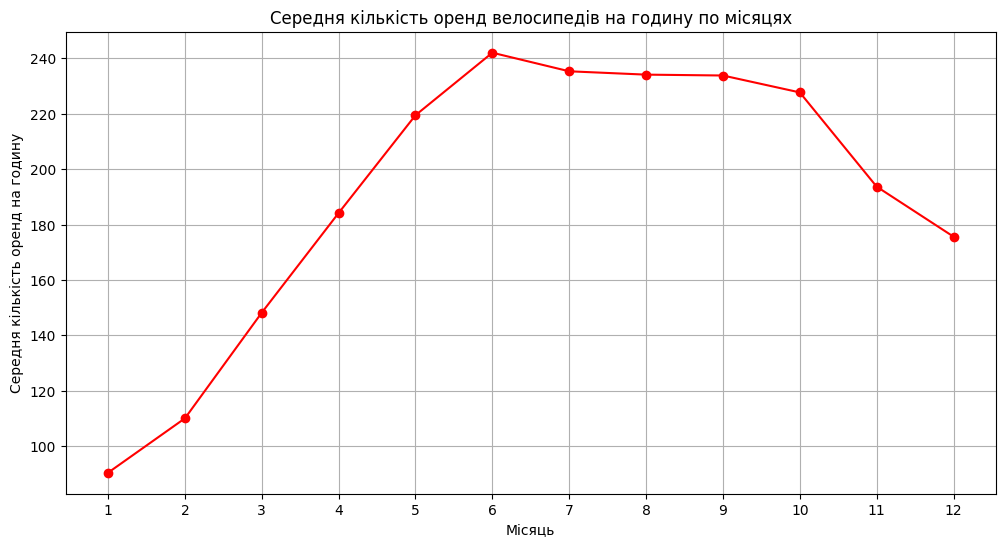

In [16]:
monthly_avg = df.groupby('month')['count'].mean()

monthly_avg.plot(marker='o', color='red', figsize=(12, 6), title='Середня кількість оренд велосипедів на годину по місяцях')
plt.grid(True)
plt.xlabel('Місяць')
plt.ylabel('Середня кількість оренд на годину')
plt.xticks(range(1, 13))  # чіткі поділки для кожного місяця (1-12)
plt.show()

1. Спостерігається пік у червні і потім на три наступні місяці значення виходить на плато та спад оренди у січні найнижчий показник. Тобто загальна форма графіка — плавне зростання від січня до червня, стабільне літнє плато (червень-вересень), а потім поступовий спад до грудня-січня.
2. Так, повністю збігається, і навіть підтверджує гіпотезу точніше. У поденному графіку ми бачили загальне зростання популярності сервісу з часом плюс річну сезонність, і зимові місяці (грудень-лютий) там теж виглядали найслабшими.
3. Графік показує пряму залежність кількості оренди велосипедів від клімату країни і сезонів.

## Завдання 4: Розподіл погодних умов (Pie Chart)

**Завдання:**
1. Побудуйте кругову діаграму з часткою записів за погодними умовами
2. Додайте підписи з відсотками та легенду з описами погоди (1=ясно, 2=туман, 3=легкий дощ, 4=сильний дощ).
3. Визначте свої відмінні від стандартних кольори для відображення кожної категорії.
4. Дайте відповіді на питання нижче.

**Питання для інтерпретації:**
1. Яка погода переважає в датасеті?
2. Чи є дні із сильним дощем? Яка їх частка?
3. Як ви думаєте, як погодні умови впливають на попит на оренду велосипедів?

Очікуваний результат:

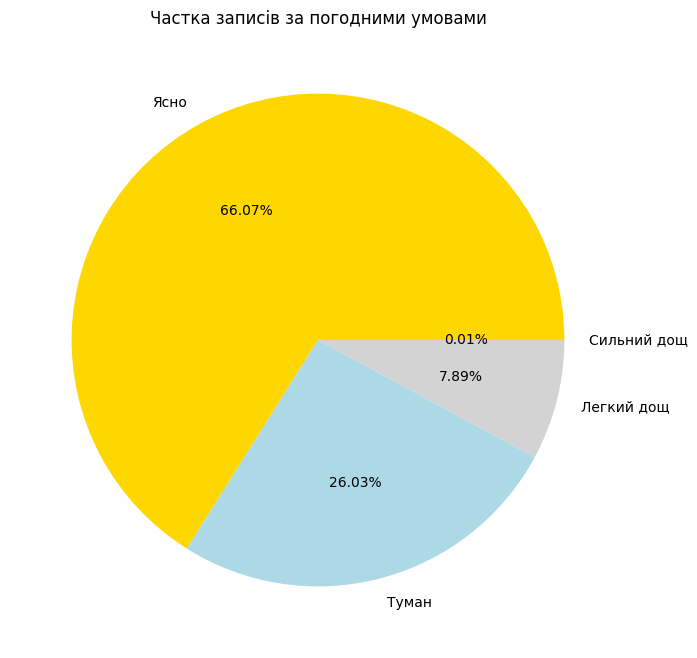

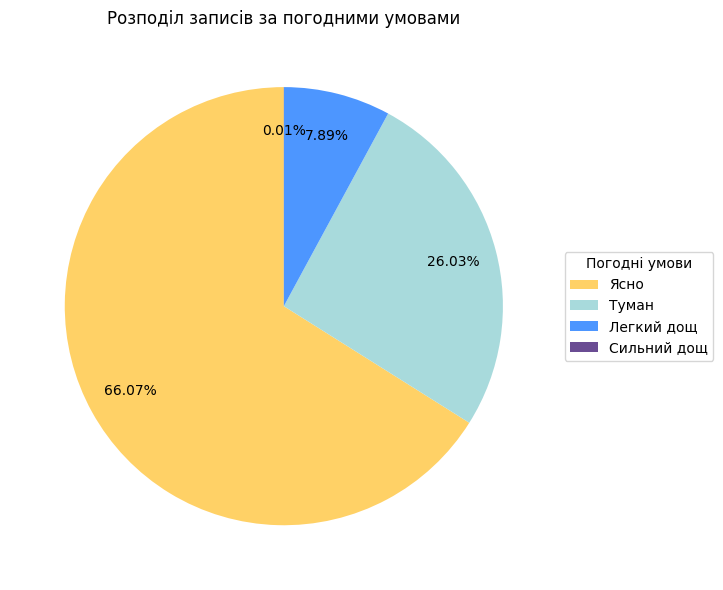

In [32]:
weather_counts = df['weather'].value_counts().sort_index()

weather_names = {
    1: 'Ясно',
    2: 'Туман',
    3: 'Легкий дощ',
    4: 'Сильний дощ'
}

weather_colors = {
    1: '#FFD166',
    2: '#A8DADC',
    3: '#4D96FF',
    4: '#6A4C93'
}

labels = [weather_names[i] for i in weather_counts.index]
colors = [weather_colors[i] for i in weather_counts.index]

plt.figure(figsize=(12, 6))

wedges, texts, autotexts = plt.pie(
    weather_counts,
    autopct='%1.2f%%',
    colors=colors,
    startangle=90,
    pctdistance=0.8
)

plt.legend(wedges, labels, title='Погодні умови', loc='center left', bbox_to_anchor=(1, 0.5))
plt.title('Розподіл записів за погодними умовами')
plt.tight_layout()
plt.show()

1.Найпоширеніша погодна умова - "Ясно" (weather=1), яка становить 66.1% усіх записів. Тобто дві третини часу спостережень погода була ясною/чистою - це домінуючий стан.
2. Сильний дощ трапляється вкрай рідко (0.01%), і будь-які висновки щодо цієї категорії варто робити з обережністю через малу вибірку.
3. Чим гірша погода, тим нижчий попит: ясно - найбільш оренд, дощ (легкий чи сильний) - різке падіння через дискомфорт і небезпеку їзди в мокру погоду.

## Завдання 5: Box Plot для аналізу викидів

**Завдання:**
Створіть коробковий графік (box plot) кількості орендованих велосипедів для кожного типу погоди.

Просунуте доповнення:
- Використайте горизонтальну орієнтацію.
- Позначте погодні умови не числом, а назвою на візуалізації.

Дайте відповіді на питання нижче.

**Питання для інтерпретації:**
1. При якій погоді найбільший розкид у кількості оренди?
2. Чи є викиди (outliers) в даних? При якій погоді?
3. При якій погоді медіанне значення оренди найвище?

<Figure size 1000x600 with 0 Axes>

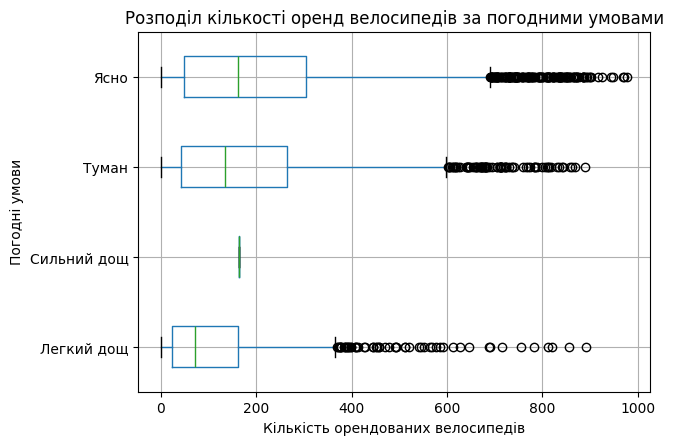

In [34]:
df['weather_label'] = df['weather'].map(weather_names)

plt.figure(figsize=(10, 6))

df.boxplot(column='count', by='weather_label', vert=False)

plt.title('Розподіл кількості оренд велосипедів за погодними умовами')
plt.suptitle('')
plt.xlabel('Кількість орендованих велосипедів')
plt.ylabel('Погодні умови')
plt.show()

1. Найбільший розкид - при ясній погоді та тумані (майже однаковий, широкий діапазон 0-600+).

2. Так, найбільше викидів - при ясній погоді й тумані (аномально високий попит у пікові години, 700-950+). При сильному дощі викидів не видно, але через мізерну вибірку (0.01%).

3. Найвища медіана - при ясній погоді (160-170), трохи нижче - туман (130-140), найнижча - легкий дощ (70).

## Завдання 6: Кореляція температури та оренди (Scatter Plot)

**Завдання:**
Побудуйте діаграму розсіювання залежності між температурою (`temp`) та загальною кількістю оренди (`count`). Розфарбуйте точки за сезонами, додайте напівпрозорість (alpha=0.6).

**Увага!** За замовченням буде колір

Дайте відповіді на питання нижче.

**Питання для інтерпретації:**
- Чи є зв'язок між температурою та кількістю оренди? Який?

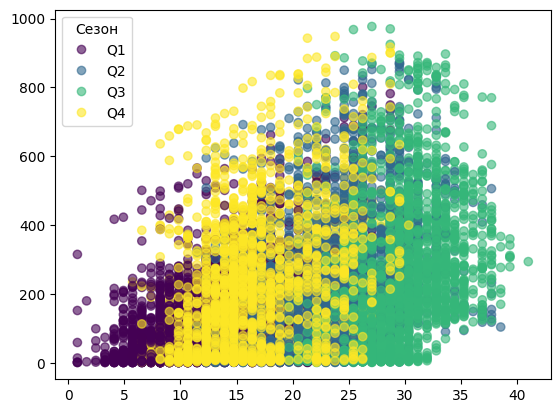

In [37]:
scatter = plt.scatter(df['temp'], df['count'], c=df['season'], cmap='viridis', alpha=0.6)
plt.legend(handles=scatter.legend_elements()[0], labels=['Q1', 'Q2', 'Q3', 'Q4'], title='Сезон')

Попит зростає з підвищенням температури до певної комфортної точки (приблизно 25-27°C), після чого стабілізується або починає знижуватись. Це типова, логічна поведінка: людям некомфортно їздити на велосипеді як у надто холодну, так і в надто спекотну погоду - існує "оптимальна" температурна зона для максимального попиту.

## (Опціонально) Завдання 7: Порівняння користувачів (Stacked Bar Chart)

**Завдання:**
Ми хочемо дізнатись як по дням тижня беруть в середньому в оренду велосипеди випадкові і зареєстровані користувачі.

Створіть стовпчасту діаграму з накопиченням (bar з налаштуванням `stacked=True`), яка показує співвідношення випадкових (`casual`) та зареєстрованих (`registered`) користувачів по днях тижня за кількістю взятих ними велосипедів в оренду в середньому. Використайте різні кольори для типів користувачів.

Дайте відповіді на питання нижче.

**Питання для інтерпретації:**
1. В які дні тижня більше оренд від зареєстрованих користувачів?
2. Як ви можете пояснити таку різницю в поведінці користувачів протягом тижня?

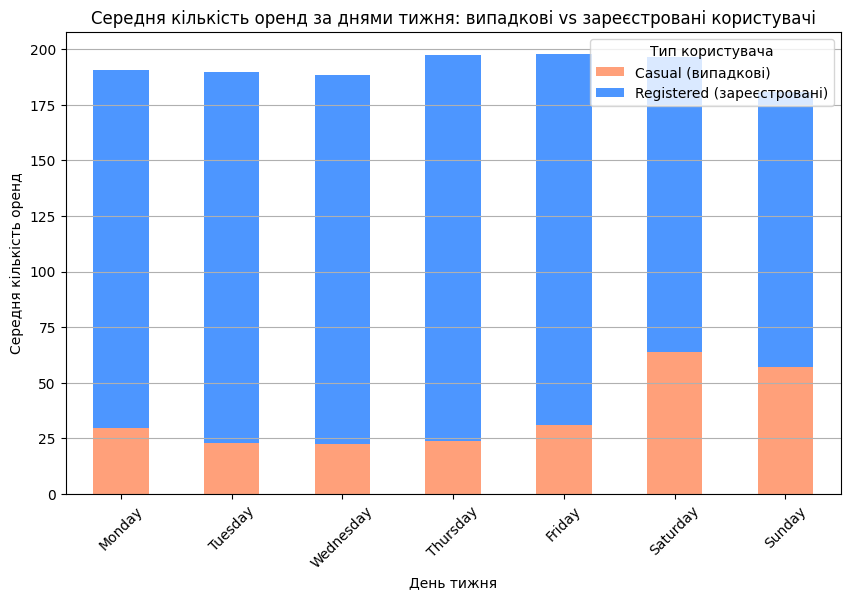

In [43]:
weekday_avg = df.groupby('weekday')[['casual', 'registered']].mean()

weekday_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
weekday_avg = weekday_avg.reindex(weekday_order)

weekday_avg.plot(kind='bar', stacked=True, color=['#FFA07A', '#4D96FF'], figsize=(10, 6))

plt.title('Середня кількість оренд за днями тижня: випадкові vs зареєстровані користувачі')
plt.xlabel('День тижня')
plt.ylabel('Середня кількість оренд')
plt.legend(title='Тип користувача', labels=['Casual (випадкові)', 'Registered (зареєстровані)'])
plt.xticks(rotation=45)
plt.grid(True, axis='y')
plt.show()

Зареєстровані користувачі - це переважно люди, які використовують велосипеди як регулярний транспорт для щоденних поїздок (на роботу/навчання): їхня активність стабільно висока й майже однакова щодня в будні (пн-пт), і саме вони формують основну масу оренд протягом тижня. Випадкові користувачі, навпаки, різко активізуються у вихідні (субота-неділя) - їхня частка зростає більш ніж удвічі порівняно з буднями. Це вказує на те, що ця група - переважно люди, які катаються для дозвілля й розваги (прогулянки, туристи, спонтанні поїздки), коли є вільний час, а не для щоденних потреб.